In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")

In [8]:
dataset = load_dataset("pubmed_qa", "pqa_labeled")

df = dataset["train"].to_pandas()

print(df.shape)
df.head()

(1000, 5)


,pubid,question,context,long_answer,final_decision
0,21645374,Do mitochondria play a role in remodelling lac...,{'contexts': ['Programmed cell death (PCD) is ...,Results depicted mitochondrial dynamics in viv...,yes
1,16418930,Landolt C and snellen e acuity: differences in...,{'contexts': ['Assessment of visual acuity dep...,"Using the charts described, there was only a s...",no
2,9488747,"Syncope during bathing in infants, a pediatric...",{'contexts': ['Apparent life-threatening event...,"""Aquagenic maladies"" could be a pediatric form...",yes
3,17208539,Are the long-term results of the transanal pul...,{'contexts': ['The transanal endorectal pull-t...,Our long-term study showed significantly bette...,no
4,10808977,Can tailored interventions increase mammograph...,{'contexts': ['Telephone counseling and tailor...,The effects of the intervention were most pron...,yes


In [9]:
print(df.columns)
print(df["context"].iloc[0])

Index(['pubid', 'question', 'context', 'long_answer', 'final_decision'], dtype='object')
{'contexts': array(['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.',
       'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), cells in early stages of PCD (EPCD), and c

In [10]:
def extract_context(x):
    if isinstance(x, dict) and "contexts" in x:
        return " ".join(x["contexts"])
    return ""

df["context_str"] = df["context"].apply(extract_context)

df["label"] = df["final_decision"]

df["full_text"] = df["question"] + " " + df["context_str"]

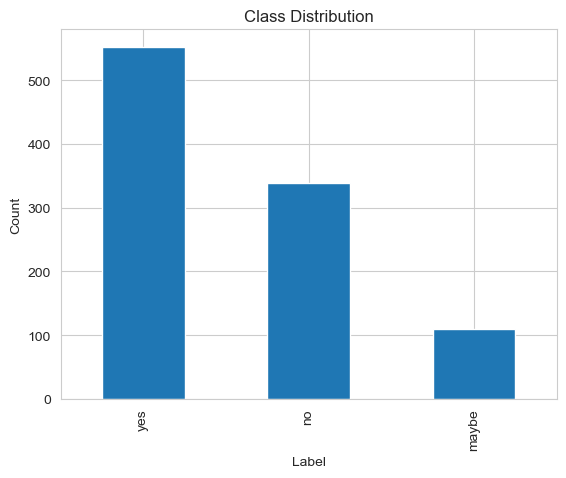

label
yes      0.552
no       0.338
maybe    0.110
Name: proportion, dtype: float64


In [11]:
plt.figure()
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(df["label"].value_counts(normalize=True))

/Users/kruthikasatish/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


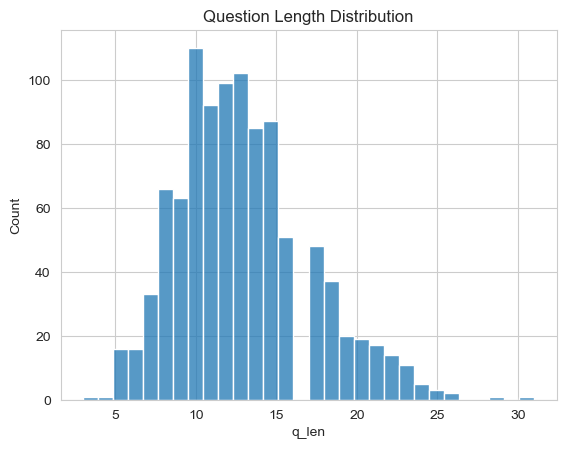

/Users/kruthikasatish/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


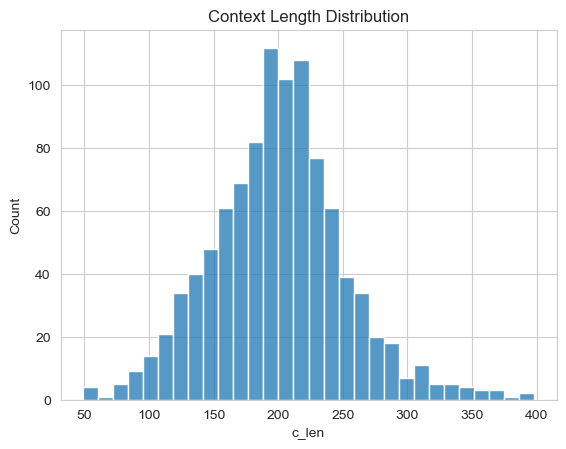

In [13]:
df["q_len"] = df["question"].apply(lambda x: len(str(x).split()))
df["c_len"] = df["context_str"].apply(lambda x: len(str(x).split()))

plt.figure()
sns.histplot(df["q_len"], bins=30)
plt.title("Question Length Distribution")
plt.show()

plt.figure()
sns.histplot(df["c_len"], bins=30)
plt.title("Context Length Distribution")
plt.show()

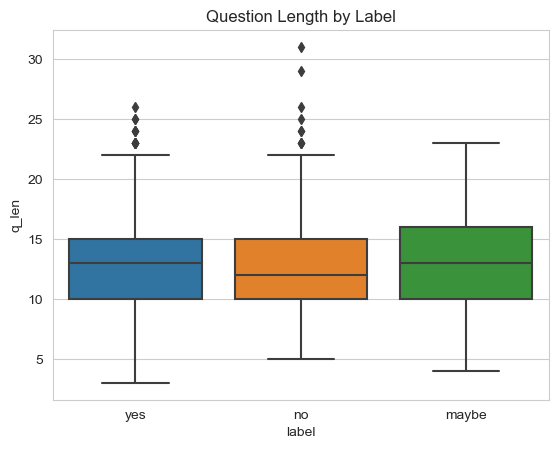

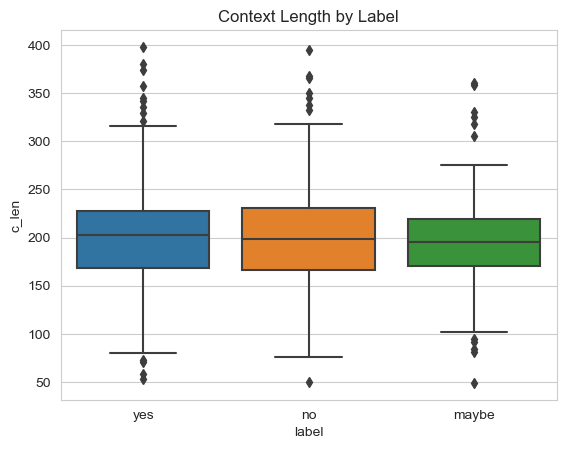

In [14]:
plt.figure()
sns.boxplot(x="label", y="q_len", data=df)
plt.title("Question Length by Label")
plt.show()

plt.figure()
sns.boxplot(x="label", y="c_len", data=df)
plt.title("Context Length by Label")
plt.show()

In [15]:
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df["full_text"])

word_freq = np.array(X.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({"word": words, "freq": word_freq})
freq_df.sort_values(by="freq", ascending=False).head(20)

,word,freq
668,patients,2569
901,study,939
434,group,861
997,years,524
147,age,472
941,treatment,456
246,compared,448
112,95,441
860,significant,437
435,groups,429


In [22]:
def get_top_words(texts, n=10):
    vec = CountVectorizer(stop_words='english')
    X = vec.fit_transform(texts)
    counts = np.array(X.sum(axis=0)).flatten()
    words = vec.get_feature_names_out()
    return pd.DataFrame({"word": words, "count": counts}) \
             .sort_values(by="count", ascending=False) \
             .head(n)

for label in df["label"].unique():
    print(f"\nTop words for {label}:")
    print(get_top_words(df[df["label"] == label]["full_text"]))


Top words for yes:
                word  count
6892        patients   1351
8913           study    525
4413           group    493
10085          years    270
2381        compared    267
771               95    265
1936          cancer    254
8148            risk    250
9487       treatment    240
8525   significantly    237

Top words for no:
             word  count
4816     patients    925
6312        study    327
3151        group    286
802           age    197
7117        years    184
3153       groups    183
6015  significant    182
7089        women    172
4111         mean    159
6682    treatment    152

Top words for maybe:
           word  count
2515   patients    293
3312      study     87
1593      group     82
708        care     77
3724      years     70
3508  treatment     64
392         age     61
34           10     60
855    compared     55
3672         vs     54


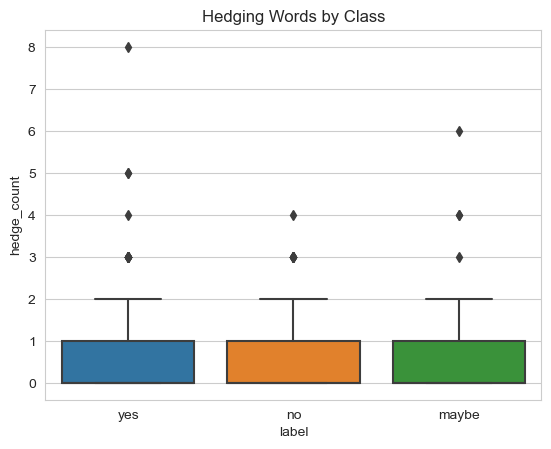

In [17]:
hedging_words = ["may", "might", "could", "suggest", "possibly", "likely", "uncertain", "limited"]

def count_hedging(text):
    text = str(text).lower()
    return sum(text.count(word) for word in hedging_words)

df["hedge_count"] = df["full_text"].apply(count_hedging)

plt.figure()
sns.boxplot(x="label", y="hedge_count", data=df)
plt.title("Hedging Words by Class")
plt.show()

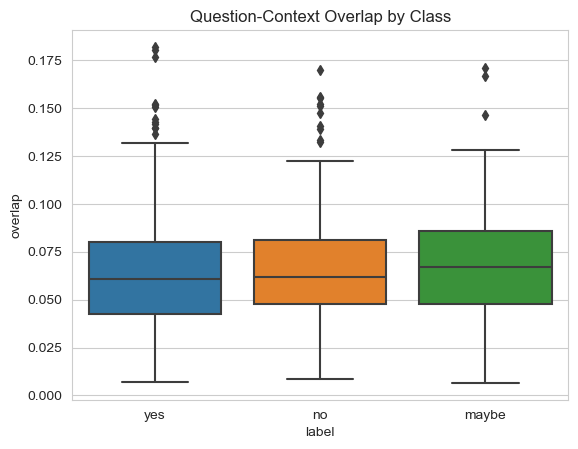

In [18]:
def jaccard(q, c):
    q_set = set(str(q).lower().split())
    c_set = set(str(c).lower().split())
    return len(q_set & c_set) / len(q_set | c_set) if len(q_set | c_set) > 0 else 0

df["overlap"] = df.apply(lambda x: jaccard(x["question"], x["context_str"]), axis=1)

plt.figure()
sns.boxplot(x="label", y="overlap", data=df)
plt.title("Question-Context Overlap by Class")
plt.show()

In [19]:
vec = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)
X = vec.fit_transform(df["full_text"])

bigrams = vec.get_feature_names_out()
counts = np.array(X.sum(axis=0)).flatten()

pd.DataFrame({"bigram": bigrams, "count": counts}) \
    .sort_values(by="count", ascending=False)

,bigram,count
0,95 ci,290
6,control group,104
19,statistically significant,96
4,breast cancer,89
1,95 confidence,87
12,patients underwent,86
5,confidence interval,85
10,mean age,81
2,aim study,79
18,significantly higher,79


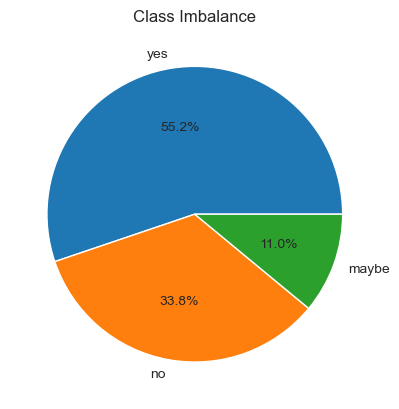

In [20]:
labels = df["label"].value_counts()

plt.figure()
plt.pie(labels, labels=labels.index, autopct='%1.1f%%')
plt.title("Class Imbalance")
plt.show()

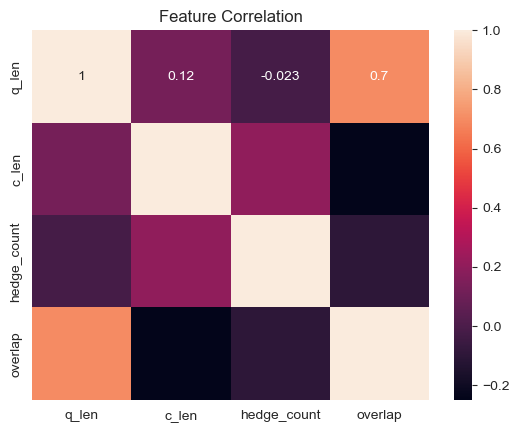

In [21]:
features = ["q_len", "c_len", "hedge_count", "overlap"]

corr = df[features].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation")
plt.show()